In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ============================================================
# COMPLETE MEMORY-EFFICIENT DATA AUGMENTATION PIPELINE
# With Robust Landmark Augmenter
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import random
import re
from collections import Counter
from tqdm import tqdm
import gc
import warnings
import os
from scipy import interpolate
from typing import Tuple, List
warnings.filterwarnings('ignore')

# ============================================================
# ROBUST DATA AUGMENTATION FOR SIGN LANGUAGE LANDMARKS
# ============================================================

class LandmarkAugmenter:
    """
    Robust data augmentation for sign language landmarks
    Preserves face and pose landmarks, only augments hands
    NO EMPTY SAMPLES - all augmentations are validated
    """
    
    def __init__(self, feature_dim=438, target_frames=120):
        self.feature_dim = feature_dim
        self.target_frames = target_frames
        
        # Feature indices (based on 438 feature format)
        self.POSE_SIZE = 132
        self.FACE_SIZE = 180
        self.HAND_SIZE = 63
        
        self.POSE_START = 0
        self.POSE_END = self.POSE_SIZE
        self.FACE_START = self.POSE_SIZE
        self.FACE_END = self.POSE_SIZE + self.FACE_SIZE
        self.LH_START = self.POSE_SIZE + self.FACE_SIZE
        self.LH_END = self.POSE_SIZE + self.FACE_SIZE + self.HAND_SIZE
        self.RH_START = self.POSE_SIZE + self.FACE_SIZE + self.HAND_SIZE
        self.RH_END = self.feature_dim
        
        self.augmentation_stats = {
            'total_attempts': 0,
            'successful': 0,
            'failed': 0,
            'empty_rejected': 0
        }
    
    def _extract_hands(self, sequence):
        lh = sequence[:, self.LH_START:self.LH_END]
        rh = sequence[:, self.RH_START:self.RH_END]
        return lh, rh
    
    def _extract_face_pose(self, sequence):
        pose = sequence[:, self.POSE_START:self.POSE_END]
        face = sequence[:, self.FACE_START:self.FACE_END]
        return pose, face
    
    def _combine_landmarks(self, pose, face, lh, rh):
        return np.concatenate([pose, face, lh, rh], axis=1)
    
    def _is_valid_sequence(self, sequence):
        if sequence is None:
            return False
        if not isinstance(sequence, np.ndarray):
            return False
        if len(sequence) == 0 or sequence.size == 0:
            return False
        if np.all(sequence == 0):
            return False
        if np.any(np.isnan(sequence)) or np.any(np.isinf(sequence)):
            return False
        if np.max(np.abs(sequence)) < 1e-6:
            return False
        return True
    
    def change_speed(self, sequence, speed_factor=None):
        if speed_factor is None:
            speed_factor = random.uniform(0.85, 1.15)
        
        T = len(sequence)
        new_length = int(T / speed_factor)
        if new_length < 2:
            return sequence.copy()
        
        old_indices = np.linspace(0, T-1, T)
        new_indices = np.linspace(0, T-1, new_length)
        
        augmented = np.zeros((new_length, self.feature_dim))
        for dim in range(self.feature_dim):
            interp_func = interpolate.interp1d(old_indices, sequence[:, dim], 
                                               kind='linear', fill_value='extrapolate')
            augmented[:, dim] = interp_func(new_indices)
        return augmented
    
    def random_speed_augment(self, sequence, prob=0.4):
        if random.random() < prob:
            speed = random.uniform(0.85, 1.15)
            return self.change_speed(sequence, speed)
        return sequence.copy()
    
    def temporal_shift(self, sequence, shift_frames=None):
        T = len(sequence)
        if shift_frames is None:
            shift_frames = random.randint(-T//8, T//8)
        
        if shift_frames == 0:
            return sequence.copy()
        
        shifted = np.zeros_like(sequence)
        
        if shift_frames > 0:
            if shift_frames < T:
                shifted[shift_frames:] = sequence[:-shift_frames]
                if np.all(shifted[:shift_frames] == 0):
                    shifted[:shift_frames] = sequence[0]
        else:
            shift_abs = abs(shift_frames)
            if shift_abs < T:
                shifted[:-shift_abs] = sequence[shift_abs:]
                if np.all(shifted[-shift_abs:] == 0):
                    shifted[-shift_abs:] = sequence[-1]
        
        if np.all(shifted == 0):
            return sequence.copy()
        return shifted
    
    def random_temporal_shift(self, sequence, prob=0.3, max_shift_ratio=0.1):
        if random.random() < prob:
            max_shift = int(len(sequence) * max_shift_ratio)
            shift = random.randint(-max_shift, max_shift)
            return self.temporal_shift(sequence, shift)
        return sequence.copy()
    
    def spatial_shift_hands(self, sequence, shift_x=None, shift_y=None):
        if shift_x is None:
            shift_x = random.uniform(-0.04, 0.04)
        if shift_y is None:
            shift_y = random.uniform(-0.04, 0.04)
        
        augmented = sequence.copy()
        lh, rh = self._extract_hands(augmented)
        lh_original, rh_original = lh.copy(), rh.copy()
        
        for i in range(0, self.HAND_SIZE, 3):
            if i + 1 < self.HAND_SIZE:
                lh[:, i] += shift_x
                lh[:, i+1] += shift_y
                rh[:, i] += shift_x
                rh[:, i+1] += shift_y
        
        if np.all(lh == 0):
            lh = lh_original
        if np.all(rh == 0):
            rh = rh_original
        
        augmented[:, self.LH_START:self.LH_END] = lh
        augmented[:, self.RH_START:self.RH_END] = rh
        return augmented
    
    def random_spatial_shift_hands(self, sequence, prob=0.4):
        if random.random() < prob:
            return self.spatial_shift_hands(sequence)
        return sequence.copy()
    
    def spatial_scale_hands(self, sequence, scale_factor=None):
        if scale_factor is None:
            scale_factor = random.uniform(0.92, 1.08)
        
        augmented = sequence.copy()
        lh, rh = self._extract_hands(augmented)
        lh_original, rh_original = lh.copy(), rh.copy()
        
        for i in range(0, self.HAND_SIZE, 3):
            if i + 1 < self.HAND_SIZE:
                lh[:, i] *= scale_factor
                lh[:, i+1] *= scale_factor
                rh[:, i] *= scale_factor
                rh[:, i+1] *= scale_factor
        
        if np.all(lh == 0):
            lh = lh_original
        if np.all(rh == 0):
            rh = rh_original
        
        augmented[:, self.LH_START:self.LH_END] = lh
        augmented[:, self.RH_START:self.RH_END] = rh
        return augmented
    
    def random_spatial_scale_hands(self, sequence, prob=0.4):
        if random.random() < prob:
            return self.spatial_scale_hands(sequence)
        return sequence.copy()
    
    def add_noise(self, sequence, noise_std=0.001):
        noise = np.random.normal(0, noise_std, sequence.shape)
        return sequence + noise
    
    def random_add_noise(self, sequence, prob=0.2):
        if random.random() < prob:
            return self.add_noise(sequence)
        return sequence.copy()
    
    def augment_hands_only(self, sequence, max_retries=5):
        original = sequence.copy()
        
        for attempt in range(max_retries):
            aug_seq = sequence.copy()
            pose, face = self._extract_face_pose(aug_seq)
            lh, rh = self._extract_hands(aug_seq)
            augmented = False
            
            if random.random() < 0.4:
                shift_x = random.uniform(-0.03, 0.03)
                shift_y = random.uniform(-0.03, 0.03)
                for i in range(0, self.HAND_SIZE, 3):
                    if i + 1 < self.HAND_SIZE:
                        lh[:, i] += shift_x
                        lh[:, i+1] += shift_y
                        rh[:, i] += shift_x
                        rh[:, i+1] += shift_y
                augmented = True
            
            if random.random() < 0.3:
                scale = random.uniform(0.94, 1.06)
                for i in range(0, self.HAND_SIZE, 3):
                    if i + 1 < self.HAND_SIZE:
                        lh[:, i] *= scale
                        lh[:, i+1] *= scale
                        rh[:, i] *= scale
                        rh[:, i+1] *= scale
                augmented = True
            
            if random.random() < 0.2:
                noise_std = random.uniform(0.0005, 0.001)
                lh += np.random.normal(0, noise_std, lh.shape)
                rh += np.random.normal(0, noise_std, rh.shape)
                augmented = True
            
            if not augmented:
                return original
            
            result = self._combine_landmarks(pose, face, lh, rh)
            
            if self._is_valid_sequence(result):
                self.augmentation_stats['successful'] += 1
                return result
            else:
                self.augmentation_stats['failed'] += 1
                continue
        
        self.augmentation_stats['empty_rejected'] += 1
        return original
    
    def get_stats(self):
        return self.augmentation_stats
    
    def reset_stats(self):
        self.augmentation_stats = {
            'total_attempts': 0,
            'successful': 0,
            'failed': 0,
            'empty_rejected': 0
        }


# ============================================================
# MEMORY-EFFICIENT DATA LOADER
# ============================================================

def scan_files(data_dir):
    """Scan all files and return metadata without loading data"""
    data_dir = Path(data_dir)
    splits_dir = data_dir / "splits"
    
    if not splits_dir.exists():
        raise FileNotFoundError(f"Splits directory not found: {splits_dir}")
    
    all_files = []
    all_labels = []
    all_splits = []
    
    for split_name in ['train', 'val', 'test']:
        split_dir = splits_dir / split_name
        if split_dir.exists():
            for file_path in split_dir.glob("*.npy"):
                if file_path.name.endswith("_mask.npy"):
                    continue
                
                filename = file_path.stem
                label = re.sub(r'\s+\d+$', '', filename)
                if '_' in label and not label[0].isdigit():
                    label = label.split('_')[0]
                
                all_files.append(file_path)
                all_labels.append(label)
                all_splits.append(split_name)
    
    print(f"📁 Found {len(all_files)} total files")
    print(f"   Train: {all_splits.count('train')}")
    print(f"   Val: {all_splits.count('val')}")
    print(f"   Test: {all_splits.count('test')}")
    
    return all_files, all_labels, all_splits


def load_single_file(file_path, max_frames=120, feature_dim=438):
    """Load and process a single file"""
    try:
        data = np.load(file_path, allow_pickle=True)
        
        # Handle different formats
        if isinstance(data, np.ndarray):
            if data.dtype == np.object_:
                if len(data) > 0 and isinstance(data[0], np.ndarray):
                    data = np.stack(data).astype(np.float32)
                else:
                    data = np.array(data, dtype=np.float32)
            elif data.dtype != np.float32:
                data = data.astype(np.float32)
        
        # Ensure 2D array
        if data.ndim == 1:
            data = data.reshape(1, -1)
        
        # Pad or truncate
        if len(data) >= max_frames:
            data = data[:max_frames]
        else:
            pad = np.zeros((max_frames - len(data), data.shape[1]), dtype=np.float32)
            data = np.vstack([data, pad])
        
        # Fix feature dimension
        if data.shape[1] != feature_dim:
            if data.shape[1] > feature_dim:
                data = data[:, :feature_dim]
            else:
                pad = np.zeros((data.shape[0], feature_dim - data.shape[1]), dtype=np.float32)
                data = np.hstack([data, pad])
        
        return data
        
    except Exception as e:
        print(f"⚠️ Error loading {file_path.name}: {e}")
        return None


# ============================================================
# MEMORY-EFFICIENT AUGMENTATION PROCESSOR
# ============================================================

class MemoryEfficientAugmentor:
    def __init__(self, output_dir, augmenter, max_frames=120, 
                 augmentations_per_sample=2, batch_size=30):
        self.output_dir = Path(output_dir)
        self.augmenter = augmenter
        self.max_frames = max_frames
        self.augmentations_per_sample = augmentations_per_sample
        self.batch_size = batch_size
        
        # Create output directories
        self.output_dir.mkdir(parents=True, exist_ok=True)
        for split in ['train', 'val', 'test']:
            (self.output_dir / split).mkdir(exist_ok=True)
        
        self.stats = {
            'original_counts': Counter(),
            'augmented_counts': Counter(),
            'total_original': 0,
            'total_augmented': 0,
            'files_processed': 0,
            'files_failed': 0
        }
    
    def save_sequence(self, seq, label, split, index, is_augmented=False, aug_idx=None):
        """Save a single sequence to disk"""
        safe_label = label.replace(' ', '_').replace('/', '_').replace('\\', '_')
        
        if is_augmented:
            filename = f"{safe_label}_{index:06d}_aug{aug_idx+1}.npy"
        else:
            filename = f"{safe_label}_{index:06d}.npy"
        
        file_path = self.output_dir / split / filename
        np.save(file_path, seq.astype(np.float32))
        return file_path
    
    def process_file(self, file_path, label, split, file_idx):
        """Process a single file: load, augment, save"""
        # Load original
        seq = load_single_file(file_path, self.max_frames)
        if seq is None:
            self.stats['files_failed'] += 1
            return False
        
        # Save original
        self.save_sequence(seq, label, split, file_idx, is_augmented=False)
        self.stats['original_counts'][label] += 1
        self.stats['total_original'] += 1
        self.stats['files_processed'] += 1
        
        # Create and save augmented versions
        for aug_idx in range(self.augmentations_per_sample):
            aug_seq = self.augmenter.augment_hands_only(seq)
            self.save_sequence(aug_seq, label, split, file_idx, 
                              is_augmented=True, aug_idx=aug_idx)
            self.stats['augmented_counts'][label] += 1
            self.stats['total_augmented'] += 1
        
        return True
    
    def process_dataset(self, files, labels, splits):
        """Process all files in batches"""
        total_files = len(files)
        num_batches = (total_files + self.batch_size - 1) // self.batch_size
        
        for batch_idx in tqdm(range(num_batches), desc="Processing batches"):
            start_idx = batch_idx * self.batch_size
            end_idx = min(start_idx + self.batch_size, total_files)
            
            for i in range(start_idx, end_idx):
                self.process_file(files[i], labels[i], splits[i], i)
            
            # Clear memory after each batch
            gc.collect()
            
            # Print progress
            if (batch_idx + 1) % 5 == 0:
                print(f"\n   Progress: {self.stats['files_processed']}/{total_files} files")
                print(f"   Original: {self.stats['total_original']}, Augmented: {self.stats['total_augmented']}")
        
        return self.stats


# ============================================================
# MAIN FUNCTION
# ============================================================

def main():
    # Configuration
    DATA_DIR = Path("/kaggle/input/datasets/mariamhany44/500-data")
    OUTPUT_DIR = Path("/kaggle/working/augmented_dataset")
    MAX_FRAMES = 120
    AUGMENTATIONS_PER_SAMPLE = 2
    BATCH_SIZE = 30
    FEATURE_DIM = 438
    RANDOM_SEED = 42
    
    # Set random seed
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    
    print("="*60)
    print("📊 MEMORY-EFFICIENT AUGMENTATION PIPELINE")
    print("="*60)
    print(f"Data directory: {DATA_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Max frames: {MAX_FRAMES}")
    print(f"Augmentations per sample: {AUGMENTATIONS_PER_SAMPLE}")
    print(f"Batch size: {BATCH_SIZE}")
    print("="*60)
    
    # Scan files
    print("\n🔍 Scanning files...")
    files, labels, splits = scan_files(DATA_DIR)
    
    if len(files) == 0:
        print("❌ No files found!")
        return
    
    # Initialize augmenter
    print("\n🔧 Initializing augmenter...")
    augmenter = LandmarkAugmenter(feature_dim=FEATURE_DIM, target_frames=MAX_FRAMES)
    
    # Create processor
    processor = MemoryEfficientAugmentor(
        output_dir=OUTPUT_DIR,
        augmenter=augmenter,
        max_frames=MAX_FRAMES,
        augmentations_per_sample=AUGMENTATIONS_PER_SAMPLE,
        batch_size=BATCH_SIZE
    )
    
    # Process dataset
    print("\n🚀 Processing dataset...")
    stats = processor.process_dataset(files, labels, splits)
    
    # Print final statistics
    print("\n" + "="*60)
    print("✅ AUGMENTATION COMPLETE!")
    print("="*60)
    print(f"\n📊 Final Statistics:")
    print(f"   Original samples: {stats['total_original']}")
    print(f"   Augmented samples: {stats['total_augmented']}")
    if stats['total_original'] > 0:
        print(f"   Augmentation factor: {stats['total_augmented']/stats['total_original']:.1f}x")
    print(f"   Original classes: {len(stats['original_counts'])}")
    print(f"   Augmented classes: {len(stats['augmented_counts'])}")
    print(f"   Files processed: {stats['files_processed']}")
    print(f"   Files failed: {stats['files_failed']}")
    
    # Print augmenter statistics
    aug_stats = augmenter.get_stats()
    print(f"\n📊 Augmenter Statistics:")
    print(f"   Successful augmentations: {aug_stats['successful']}")
    print(f"   Failed augmentations: {aug_stats['failed']}")
    print(f"   Empty rejected: {aug_stats['empty_rejected']}")
    
    print(f"\n💾 Output saved to: {OUTPUT_DIR}")
    print("="*60)
    
    return stats


# ============================================================
# LOAD AUGMENTED DATA (Memory efficient)
# ============================================================

def load_augmented_data_generator(data_dir="/kaggle/working/augmented_dataset", batch_size=50):
    """Generator to load augmented data in batches"""
    data_dir = Path(data_dir)
    
    for split in ['train', 'val', 'test']:
        split_dir = data_dir / split
        if not split_dir.exists():
            continue
        
        files = list(split_dir.glob("*.npy"))
        files = [f for f in files if not f.name.endswith("_mask.npy")]
        
        for i in range(0, len(files), batch_size):
            batch_files = files[i:i+batch_size]
            batch_data = []
            batch_labels = []
            
            for file_path in batch_files:
                data = np.load(file_path)
                batch_data.append(data)
                label = file_path.stem.split('_')[0]
                batch_labels.append(label)
            
            yield {
                'data': np.array(batch_data, dtype=object),
                'labels': np.array(batch_labels),
                'split': split,
                'files': batch_files
            }
            
            del batch_data
            gc.collect()


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    stats = main()
    
    # Test loading a small batch
    print("\n🔍 Testing load with generator...")
    try:
        generator = load_augmented_data_generator("/kaggle/working/augmented_dataset", batch_size=10)
        first_batch = next(generator)
        print(f"   First batch: {len(first_batch['data'])} samples from {first_batch['split']} split")
        print(f"   Sample shape: {first_batch['data'][0].shape}")
    except StopIteration:
        print("   No data to test")

📊 MEMORY-EFFICIENT AUGMENTATION PIPELINE
Data directory: /kaggle/input/datasets/mariamhany44/500-data
Output directory: /kaggle/working/augmented_dataset
Max frames: 120
Augmentations per sample: 2
Batch size: 30

🔍 Scanning files...
📁 Found 16014 total files
   Train: 11014
   Val: 2150
   Test: 2850

🔧 Initializing augmenter...

🚀 Processing dataset...


Processing batches:   1%|          | 5/534 [00:01<02:38,  3.34it/s]


   Progress: 150/16014 files
   Original: 150, Augmented: 300


Processing batches:   2%|▏         | 10/534 [00:02<02:31,  3.46it/s]


   Progress: 300/16014 files
   Original: 300, Augmented: 600


...


   Progress: 15750/16014 files
   Original: 15750, Augmented: 31500


Processing batches:  99%|█████████▉| 530/534 [02:38<00:01,  3.87it/s]


   Progress: 15900/16014 files
   Original: 15900, Augmented: 31800


Processing batches: 100%|██████████| 534/534 [02:39<00:00,  3.35it/s]



✅ AUGMENTATION COMPLETE!

📊 Final Statistics:
   Original samples: 16014
   Augmented samples: 32028
   Augmentation factor: 2.0x
   Original classes: 485
   Augmented classes: 485
   Files processed: 16014
   Files failed: 0

📊 Augmenter Statistics:
   Successful augmentations: 21411
   Failed augmentations: 0
   Empty rejected: 0

💾 Output saved to: /kaggle/working/augmented_dataset

🔍 Testing load with generator...
   First batch: 10 samples from train split
   Sample shape: (120, 438)


Using device: cpu (forced due to CUDA compatibility issues)
Using 4 CPU threads
📊 SCANNING AUGMENTED DATA
✅ Found files:
   Train: 33042
   Validation: 6450
   Test: 8550

📊 Data Information:
   Feature dimension: 438
   Target frames: 120

🏷️ Label encoding complete: 473 classes

📊 Split sizes:
   Train: 33042 samples
   Validation: 6450 samples
   Test: 8550 samples

✅ DataLoaders created:
   Train batches: 8261
   Val batches: 1613
   Test batches: 2138

📐 MODEL ARCHITECTURE:
   Input: 438 x 120
   Architecture: TCN with 3 layers, 64 channels
   Total parameters: 205,529

🚀 STARTING CPU TRAINING
   Device: cpu
   Training samples: 33042
   Validation samples: 6450
   Test samples: 8550
   Batch size: 4
   Model parameters: 205,529
   CPU Threads: 4
⚠️ Note: CPU training will be slower but should work reliably

Epoch 1/100
📊 Epoch 001/100 | LR: 1.00e-03 | Train Loss: 5.8000 | Train Acc: 0.0398 | Val Loss: 4.6950 | Val Acc: 0.0926
  ✅ Best model saved! (Val Acc: 0.0926)

Epoch 2/100
📊

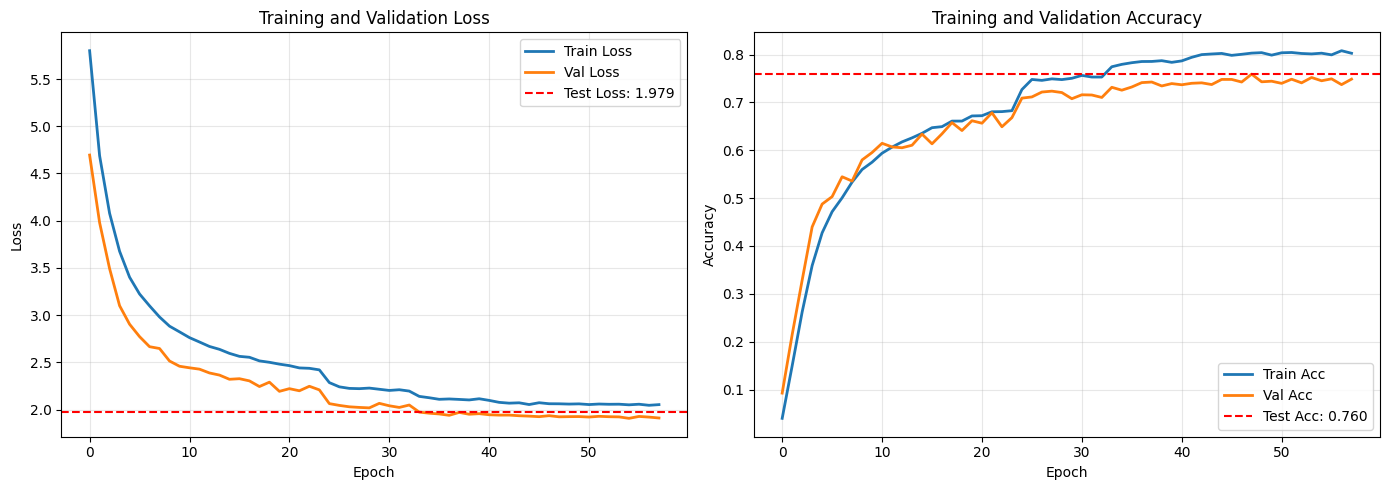

📊 Training plots saved to 'training_results_augmented_cpu.png'

✅ TRAINING COMPLETE!


In [3]:
# ============================================================
# MEMORY-EFFICIENT TRAINING ON AUGMENTED DATA (CPU VERSION)
# ============================================================

import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import pickle
import warnings
import gc
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import multiprocessing

# ============================================================
# CONFIGURATION - FORCE CPU
# ============================================================

# FORCE CPU to avoid CUDA compatibility issues
DEVICE = "cpu"
print(f"Using device: {DEVICE} (forced due to CUDA compatibility issues)")

# Optimize for CPU training
torch.set_num_threads(multiprocessing.cpu_count())
print(f"Using {torch.get_num_threads()} CPU threads")

# Paths
AUGMENTED_DATA_DIR = Path("/kaggle/working/augmented_dataset")
MODEL_SAVE_PATH = "tcn_model_augmented_cpu.pth"

# Memory-efficient training parameters
BATCH_SIZE = 4  # Smaller batch size for CPU
EPOCHS = 100  # Reduced epochs for CPU training
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 10
GRAD_CLIP = 1.0
LABEL_SMOOTH = 0.1

# ============================================================
# MEMORY-EFFICIENT DATA LOADING (Generator)
# ============================================================

def get_file_paths(data_dir):
    """Get file paths without loading data"""
    data_dir = Path(data_dir)
    file_info = []
    
    for split in ['train', 'val', 'test']:
        split_dir = data_dir / split
        if split_dir.exists():
            for file_path in split_dir.glob("*.npy"):
                if file_path.name.endswith("_mask.npy"):
                    continue
                
                filename = file_path.stem
                label = filename.split('_')[0]
                file_info.append({
                    'path': file_path,
                    'label': label,
                    'split': split
                })
    
    return file_info


class LazyLoadingDataset(Dataset):
    """Dataset that loads data on-the-fly (memory efficient)"""
    def __init__(self, file_paths, labels, target_frames=120, feature_dim=438, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.target_frames = target_frames
        self.feature_dim = feature_dim
        self.augment = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # Load data on demand (not all at once)
        data = np.load(self.file_paths[idx])
        
        # Ensure correct shape
        if data.shape[0] != self.target_frames:
            if data.shape[0] > self.target_frames:
                data = data[:self.target_frames]
            else:
                pad = np.zeros((self.target_frames - data.shape[0], self.feature_dim), dtype=np.float32)
                data = np.vstack([data, pad])
        
        # Simple augmentation for training
        if self.augment:
            if np.random.random() > 0.5:
                data = data + np.random.normal(0, 0.01, data.shape)
            if np.random.random() > 0.5:
                data = data * np.random.uniform(0.9, 1.1)
        
        # Convert to tensor and transpose for Conv1d
        x = torch.from_numpy(data).float().transpose(0, 1)
        m = torch.ones(self.target_frames, dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return x, m, y


# ============================================================
# LOAD FILE PATHS (Not actual data)
# ============================================================

print("="*60)
print("📊 SCANNING AUGMENTED DATA")
print("="*60)

file_info = get_file_paths(AUGMENTED_DATA_DIR)

if len(file_info) == 0:
    print("❌ No data found!")
    exit()

# Group by split
train_files = [f for f in file_info if f['split'] == 'train']
val_files = [f for f in file_info if f['split'] == 'val']
test_files = [f for f in file_info if f['split'] == 'test']

print(f"✅ Found files:")
print(f"   Train: {len(train_files)}")
print(f"   Validation: {len(val_files)}")
print(f"   Test: {len(test_files)}")

# ============================================================
# GET DIMENSIONS FROM FIRST FILE
# ============================================================

sample_data = np.load(train_files[0]['path'])
FEATURE_DIM = sample_data.shape[1]
TARGET_FRAMES = sample_data.shape[0]

print(f"\n📊 Data Information:")
print(f"   Feature dimension: {FEATURE_DIM}")
print(f"   Target frames: {TARGET_FRAMES}")

# ============================================================
# ENCODE LABELS (From file paths only)
# ============================================================

all_labels = [f['label'] for f in file_info]
le = LabelEncoder()
all_labels_encoded = le.fit_transform(all_labels)
num_classes = len(le.classes_)

np.save('label_encoder_augmented.npy', le.classes_)
print(f"\n🏷️ Label encoding complete: {num_classes} classes")

# Create label mapping for each file
label_map = {f['path']: label for f, label in zip(file_info, all_labels_encoded)}

# Split labels
train_labels = [label_map[f['path']] for f in train_files]
val_labels = [label_map[f['path']] for f in val_files]
test_labels = [label_map[f['path']] for f in test_files]

train_paths = [f['path'] for f in train_files]
val_paths = [f['path'] for f in val_files]
test_paths = [f['path'] for f in test_files]

print(f"\n📊 Split sizes:")
print(f"   Train: {len(train_paths)} samples")
print(f"   Validation: {len(val_paths)} samples")
print(f"   Test: {len(test_paths)} samples")

# ============================================================
# CREATE DATALOADERS (Lazy loading)
# ============================================================

# Use smaller batch size for memory efficiency
BATCH_SIZE = min(BATCH_SIZE, len(train_paths))
NUM_WORKERS = 0  # Set to 0 to avoid multiprocessing issues on CPU

train_dataset = LazyLoadingDataset(train_paths, train_labels, TARGET_FRAMES, FEATURE_DIM, augment=True)
val_dataset = LazyLoadingDataset(val_paths, val_labels, TARGET_FRAMES, FEATURE_DIM, augment=False)
test_dataset = LazyLoadingDataset(test_paths, test_labels, TARGET_FRAMES, FEATURE_DIM, augment=False)

# Calculate class weights for balanced sampling
class_counts = np.bincount(train_labels)
class_weights = 1.0 / (class_counts + 1e-6)
sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, 
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=NUM_WORKERS, pin_memory=False)

print(f"\n✅ DataLoaders created:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

# ============================================================
# OPTIMIZED TCN MODEL FOR CPU
# ============================================================

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dilation):
        super().__init__()
        padding = dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(0.25),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, 3, padding=padding, dilation=dilation),
            nn.BatchNorm1d(out_channels),
            nn.Dropout(0.25),
            nn.ReLU(inplace=True),
        )
        self.res = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        y = self.net(x)
        if y.size(2) != x.size(2):
            y = y[..., :x.size(2)]
        return y + self.res(x)


class TCN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Reduced model size for CPU efficiency
        channels = [64, 64, 64]  # 3 layers, 64 channels
        
        layers = []
        for i, c in enumerate(channels):
            in_dim = input_dim if i == 0 else channels[i-1]
            layers.append(TemporalBlock(in_dim, c, dilation=2**i))
        
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], num_classes)
        self.dropout = nn.Dropout(0.4)
        
    def masked_pool(self, x, mask):
        mask = mask.unsqueeze(1)
        masked_x = x * mask
        summed = masked_x.sum(dim=2)
        valid_counts = mask.sum(dim=2).clamp(min=1)
        return summed / valid_counts
    
    def forward(self, x, mask):
        x = self.tcn(x)
        x = self.masked_pool(x, mask)
        x = self.dropout(x)
        return self.fc(x)


# Initialize model on CPU
model = TCN(input_dim=FEATURE_DIM, num_classes=num_classes).to(DEVICE)

# Calculate model size
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📐 MODEL ARCHITECTURE:")
print(f"   Input: {FEATURE_DIM} x {TARGET_FRAMES}")
print(f"   Architecture: TCN with 3 layers, 64 channels")
print(f"   Total parameters: {total_params:,}")

# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

if num_classes > 1:
    try:
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(train_labels),
            y=train_labels
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    except:
        class_weights = None
        print("⚠️ Could not compute class weights, using uniform weights")
else:
    class_weights = None


class SmoothCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight = weight
        
    def forward(self, logits, targets):
        n_classes = logits.size(1)
        if n_classes == 1:
            return nn.functional.binary_cross_entropy_with_logits(logits.squeeze(), targets.float())
        
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        
        log_probs = torch.log_softmax(logits, dim=1)
        
        if self.weight is not None:
            weight = self.weight[targets]
            loss = -(true_dist * log_probs).sum(dim=1) * weight
        else:
            loss = -(true_dist * log_probs).sum(dim=1)
            
        return loss.mean()


criterion = SmoothCrossEntropy(smoothing=LABEL_SMOOTH, weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)  # Reduced patience for CPU

# ============================================================
# TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (x, m, y) in enumerate(loader):
        x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(x, m)
        loss = criterion(outputs, y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        
        total_loss += loss.item() * y.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(y).sum().item()
        total += y.size(0)
        
        # Print progress every 100 batches
        # if batch_idx % 100 == 0:
        #     print(f"   Batch {batch_idx}/{len(loader)} - Loss: {loss.item():.4f}")
        
        # Clear memory
        del x, m, y, outputs, loss
    
    return total_loss / total, correct / total


def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, m, y in loader:
            x, m, y = x.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
            outputs = model(x, m)
            loss = criterion(outputs, y)
            
            total_loss += loss.item() * y.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()
            total += y.size(0)
            
            # Clear memory
            del x, m, y, outputs, loss
    
    return total_loss / total, correct / total

# ============================================================
# TRAINING LOOP
# ============================================================

print("\n" + "="*60)
print("🚀 STARTING CPU TRAINING")
print("="*60)
print(f"   Device: {DEVICE}")
print(f"   Training samples: {len(train_paths)}")
print(f"   Validation samples: {len(val_paths)}")
print(f"   Test samples: {len(test_paths)}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Model parameters: {total_params:,}")
print(f"   CPU Threads: {torch.get_num_threads()}")
print("="*60)
print("⚠️ Note: CPU training will be slower but should work reliably")
print("="*60)

best_val_acc = 0
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    
    train_loss, train_acc = train_one_epoch(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_loss, val_acc = evaluate(val_loader)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"📊 Epoch {epoch+1:03d}/{EPOCHS} | "
          f"LR: {current_lr:.2e} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss,
        }, MODEL_SAVE_PATH)
        print(f"  ✅ Best model saved! (Val Acc: {val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}")
            break
    
    # Force garbage collection after each epoch
    gc.collect()

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\n" + "="*60)
print("📊 FINAL EVALUATION")
print("="*60)

# Load best model
try:
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=torch.device(DEVICE))
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
    print(f"   Validation Accuracy: {checkpoint['val_acc']:.4f}")
    
    # Test evaluation
    test_loss, test_acc = evaluate(test_loader)
    print(f"\n🎯 TEST SET RESULTS:")
    print(f"   Test Loss: {test_loss:.4f}")
    print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    
except FileNotFoundError:
    print("⚠️ No best model saved. Training might have failed.")
    test_acc = 0
    test_loss = 0

# ============================================================
# SAVE RESULTS
# ============================================================

history = {
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'num_classes': num_classes,
    'target_frames': TARGET_FRAMES,
    'feature_dim': FEATURE_DIM,
    'model_params': total_params,
}

with open('training_history_augmented_cpu.pkl', 'wb') as f:
    pickle.dump(history, f)

print(f"\n💾 Saved files:")
print(f"   Model: {MODEL_SAVE_PATH}")
print(f"   Label encoder: label_encoder_augmented.npy")
print(f"   Training history: training_history_augmented_cpu.pkl")

# ============================================================
# PLOT RESULTS (Optional)
# ============================================================

try:
    import matplotlib.pyplot as plt
    
    if len(train_losses) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].plot(train_losses, label='Train Loss', linewidth=2)
        axes[0].plot(val_losses, label='Val Loss', linewidth=2)
        axes[0].axhline(y=test_loss, color='r', linestyle='--', label=f'Test Loss: {test_loss:.3f}')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(train_accs, label='Train Acc', linewidth=2)
        axes[1].plot(val_accs, label='Val Acc', linewidth=2)
        axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f'Test Acc: {test_acc:.3f}')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title('Training and Validation Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('training_results_augmented_cpu.png', dpi=150)
        plt.show()
        print("📊 Training plots saved to 'training_results_augmented_cpu.png'")
    else:
        print("⚠️ No training data to plot")
    
except Exception as e:
    print(f"⚠️ Could not plot: {e}")

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)